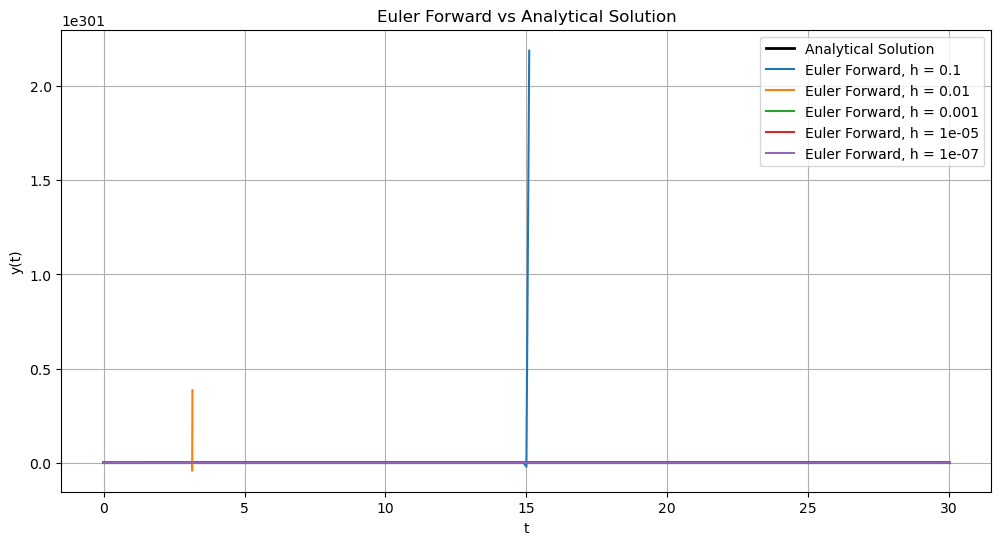

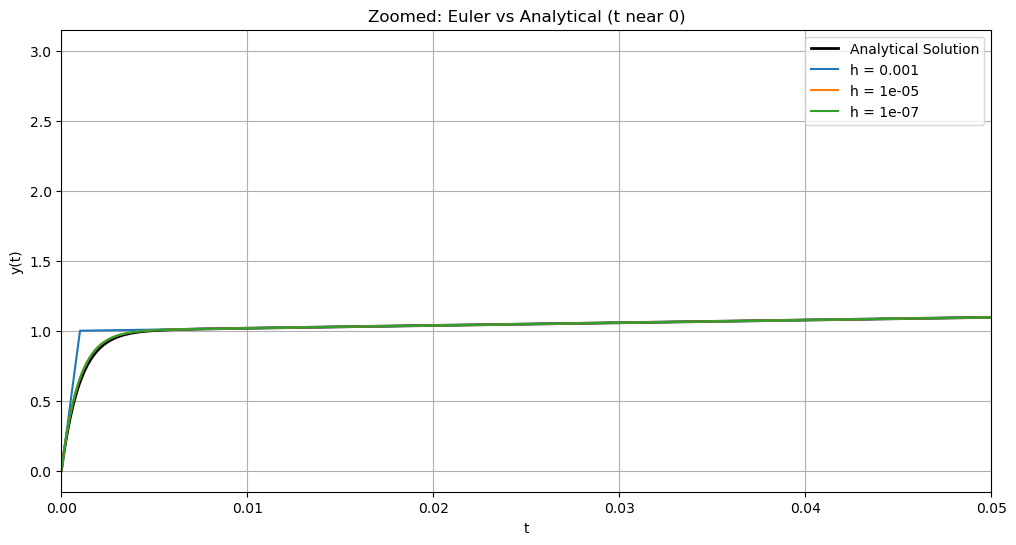

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Euler's Forward vs Analytical Solution
# ODE: dy/dt = -1000y + 3000 - 2000e^(-t),   y(0) = 0
# Analytical solution:
# y(t) = 3 - 0.998e^(-1000t) - 2.002e^(-t)

# step sizes
h_values = [0.1, 0.01, 0.001, 0.00001, 0.0000001]

# Time interval
t_start = 0
t_end = 30

# Initial condition
y0 = 0

# differential equation
def f(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)

# analytical solution
def y_exact(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

# Plot
plt.figure(figsize=(12, 6))

t_exact = np.linspace(t_start, t_end, 5000)
plt.plot(t_exact, y_exact(t_exact), 'k', linewidth=2, label='Analytical Solution')

# Euler Forward for each h
for h in h_values:
    # limit the number of points for very small h so the code can still run
    max_points = 200000

    t_values = np.arange(t_start, t_end + h, h)
    if len(t_values) > max_points:
        t_values = np.linspace(t_start, t_end, max_points)

    y_values = np.zeros(len(t_values))
    y_values[0] = y0

    for i in range(len(t_values) - 1):
        t_n = t_values[i]
        y_n = y_values[i]
        dt = t_values[i + 1] - t_values[i]

        # stop if y is already too large
        if not np.isfinite(y_n) or abs(y_n) > 1e300:
            y_values[i + 1:] = np.nan
            break

        with np.errstate(over='ignore', invalid='ignore'):
            slope = f(t_n, y_n)
            y_next = y_n + dt * slope

        if not np.isfinite(y_next):
            y_values[i + 1:] = np.nan
            break

        y_values[i + 1] = y_next

    plt.plot(t_values, y_values, label=f"Euler Forward, h = {h}")

plt.xlabel('t')
plt.ylabel('y(t)')
plt.title("Euler Forward vs Analytical Solution")
plt.legend()
plt.grid(True)
plt.show()


# Zoomed-in plot near t = 0 using only smaller h values
plt.figure(figsize=(12, 6))

t_exact_zoom = np.linspace(0, 0.05, 5000)
plt.plot(t_exact_zoom, y_exact(t_exact_zoom), 'k', linewidth=2, label='Analytical Solution')

stable_h_values = [0.001, 0.00001, 0.0000001]

for h in stable_h_values:
    max_points = 200000

    t_values = np.arange(t_start, t_end + h, h)
    if len(t_values) > max_points:
        t_values = np.linspace(t_start, t_end, max_points)

    y_values = np.zeros(len(t_values))
    y_values[0] = y0

    for i in range(len(t_values) - 1):
        t_n = t_values[i]
        y_n = y_values[i]
        dt = t_values[i + 1] - t_values[i]

        if not np.isfinite(y_n) or abs(y_n) > 1e300:
            y_values[i + 1:] = np.nan
            break

        with np.errstate(over='ignore', invalid='ignore'):
            slope = f(t_n, y_n)
            y_next = y_n + dt * slope

        if not np.isfinite(y_next):
            y_values[i + 1:] = np.nan
            break

        y_values[i + 1] = y_next

    plt.plot(t_values, y_values, label=f"h = {h}")

plt.xlim(0, 0.05)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title("Zoomed: Euler vs Analytical (t near 0)")
plt.legend()
plt.grid(True)
plt.show()

# Euler’s Forward was used to approximate the solution for multiple step sizes. 
# Larger step sizes produced unstable solutions, while smaller step sizes closely matched the analytical solution. 
# The zoomed-in plot near t=0  shows that decreasing h improves accuracy, 
# demonstrating that this is a stiff equation requiring very small step sizes for Euler’s Method to be effective.